# Foundation

In [6]:
import sys
from pathlib import Path
import torch

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"
sys.path.append(str(SRC_DIR))

from grokking_carries.config import ModelConfig
from grokking_carries.model.transformer import GrokkingCarriesTransformer
from grokking_carries.data.tokenizer import MathTokenizer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

cfg = ModelConfig()
tokenizer = MathTokenizer()

model = GrokkingCarriesTransformer(cfg).to(device)

weights_path = SRC_DIR / "grokking_carries" / "model" / "grokking_model_5_epochs.pth"

# Загружаем веса (map_location страхует от конфликтов, если обучал на GPU, а открыл на CPU)
model.load_state_dict(torch.load(weights_path, map_location=device))

# КРИТИЧЕСКИ ВАЖНО ДЛЯ ПРОБИНГА: Переводим модель в режим оценки.
model.eval()

# Замораживаем градиенты самой модели, чтобы случайно не сбить веса при обучении проба
for param in model.parameters():
    param.requires_grad = False

print("Done, the model is ready for preparation.")

Device: cpu
Done, the model is ready for preparation.


# Ground Truth generation

In [7]:
def extract_probe_labels(token_list: list[str]) -> dict[int, int]:
    """
    Проходит по токенизированному уравнению и находит индексы цифр ответа.
    Смотрит на следующий за цифрой токен, чтобы определить метку для текущей цифры.
    Возвращает словарь {индекс_в_последовательности: метка_0_или_1}
    """
    labels = {}
    
    try:
        eq_idx = token_list.index('=')
    except ValueError:
        return labels # пропускаем строку

    for i in range(eq_idx + 1, len(token_list) - 1):
        current_token = token_list[i]
        next_token = token_list[i + 1]

        # Нас интересуют только цифры ответа. 
        # Если за текущей цифрой идет токен переноса - мы нашли нужную пару!
        if current_token.isdigit() and next_token in ['<c0>', '<c1>']:
            label = 1 if next_token == '<c1>' else 0
            labels[i] = label

    return labels

In [8]:
test_equation = "0 0 0 4 5 + 0 0 0 9 2 = <c0> 7 <c1> 3 <c0> 1 <c0> 0 <c0> 0 <c0> 0"
test_tokens = test_equation.split() 

print("Исходные токены:", test_tokens)

# Получаем индексы и метки
ground_truth = extract_probe_labels(test_tokens)

for idx, label in ground_truth.items():
    print(f"Индекс [{idx}]: Токен '{test_tokens[idx]}' -> Следующим шагом предсказывает перенос: {label}")

Исходные токены: ['0', '0', '0', '4', '5', '+', '0', '0', '0', '9', '2', '=', '<c0>', '7', '<c1>', '3', '<c0>', '1', '<c0>', '0', '<c0>', '0', '<c0>', '0']
Индекс [13]: Токен '7' -> Следующим шагом предсказывает перенос: 1
Индекс [15]: Токен '3' -> Следующим шагом предсказывает перенос: 0
Индекс [17]: Токен '1' -> Следующим шагом предсказывает перенос: 0
Индекс [19]: Токен '0' -> Следующим шагом предсказывает перенос: 0
Индекс [21]: Токен '0' -> Следующим шагом предсказывает перенос: 0


# Activations extraction

In [9]:
import numpy as np

activation_cache = {} # куда хуки будут скидывать векторы

def cache_hook(tensor, hook_name):
    """
    Функция-перехватчик. 
    tensor.shape = [batch, seq_len, d_model]
    """
    activation_cache[hook_name] = tensor.detach().cpu() # detach() — экономия памяти, .cpu() перенос в ОЗУ с видеопамяти
    return tensor

def collect_activations(model, equations_list, tokenizer):
    X_per_layer = {layer: [] for layer in range(model.cfg.n_layers)}
    Y = []
    
    # готовим трекеры, которые повесим на каждый слой
    hooks_to_add = []
    for layer in range(model.cfg.n_layers):
        hooks_to_add.append((f"blocks.{layer}.mlp.hook_post", cache_hook))
        
    print(f"Начинаем сбор улик. Устанавливаем {len(hooks_to_add)} хуков...")

    for eq_str in equations_list:
        tokens_str = eq_str.split()
        labels_dict = extract_probe_labels(tokens_str)
        if not labels_dict:
            continue

        input_ids = tokenizer.encode([eq_str], pad_to_max=False).to(device)

        activation_cache.clear()
        with model.hooks(fwd_hooks=hooks_to_add):
            _ = model(input_ids) 

        for seq_idx, label in labels_dict.items():
            Y.append(label)
            
            for layer in range(model.cfg.n_layers):
                hook_name = f"blocks.{layer}.mlp.hook_post"
                vector = activation_cache[hook_name][0, seq_idx, :].numpy()
                X_per_layer[layer].append(vector)

    for layer in range(model.cfg.n_layers):
        X_per_layer[layer] = np.array(X_per_layer[layer])
    Y = np.array(Y)
    
    return X_per_layer, Y

In [10]:
test_dataset = [
    "0 0 0 4 5 + 0 0 0 9 2 = <c0> 7 <c1> 3 <c0> 1 <c0> 0 <c0> 0 <c0> 0",
    "0 0 0 1 1 + 0 0 0 2 2 = <c0> 3 <c0> 3 <c0> 0 <c0> 0 <c0> 0 <c0> 0"
]

print("Извлекаем векторы...")
X_layers, y_true = collect_activations(model, test_dataset, tokenizer)

print("\n--- Отчет об уликах ---")
print(f"Всего собрано векторов (примеров для обучения): {len(y_true)}")
print(f"Распределение меток (0 - нет переноса, 1 - есть): {np.bincount(y_true)}")
for layer in range(cfg.n_layers):
    print(f"Размерность матрицы X на слое {layer}: {X_layers[layer].shape}")

Извлекаем векторы...
Начинаем сбор улик. Устанавливаем 4 хуков...

--- Отчет об уликах ---
Всего собрано векторов (примеров для обучения): 10
Распределение меток (0 - нет переноса, 1 - есть): [9 1]
Размерность матрицы X на слое 0: (10, 1024)
Размерность матрицы X на слое 1: (10, 1024)
Размерность матрицы X на слое 2: (10, 1024)
Размерность матрицы X на слое 3: (10, 1024)


# Probe training and visualization

In [24]:
import json
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

equations_batch = []
try:
    with open("../data/test.jsonl", "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if i >= 500:
                break
            data = json.loads(line)
            equations_batch.append(data["text"])
    print(f"Загружено {len(equations_batch)} уравнений из test.jsonl.")
except FileNotFoundError:
    print("Файл test.jsonl не найден. Проверь путь.")

X_layers_full, y_full = collect_activations(model, equations_batch, tokenizer)

total_vectors = len(y_full)
positive_cases = sum(y_full)
print(f"\nИзвлечено векторов: {total_vectors}")
print(f"Из них с переносом: {positive_cases} ({positive_cases/total_vectors*100:.1f}%)")

accuracies = []

for layer in range(model.cfg.n_layers):
    X = X_layers_full[layer]
    y = y_full
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    probe = LogisticRegression(max_iter=2000, random_state=42)
    probe.fit(X_train, y_train)
    
    preds = probe.predict(X_test)
    acc = accuracy_score(y_test, preds)
    accuracies.append(acc)
    
    print(f"Слой {layer}: Точность проба = {acc:.4f}")

base_rate = max(1 - positive_cases/total_vectors, positive_cases/total_vectors)

Загружено 500 уравнений из test.jsonl.
Начинаем сбор улик. Устанавливаем 4 хуков...

Извлечено векторов: 2500
Из них с переносом: 372 (14.9%)
Слой 0: Точность проба = 0.9540
Слой 1: Точность проба = 0.9900
Слой 2: Точность проба = 1.0000
Слой 3: Точность проба = 1.0000


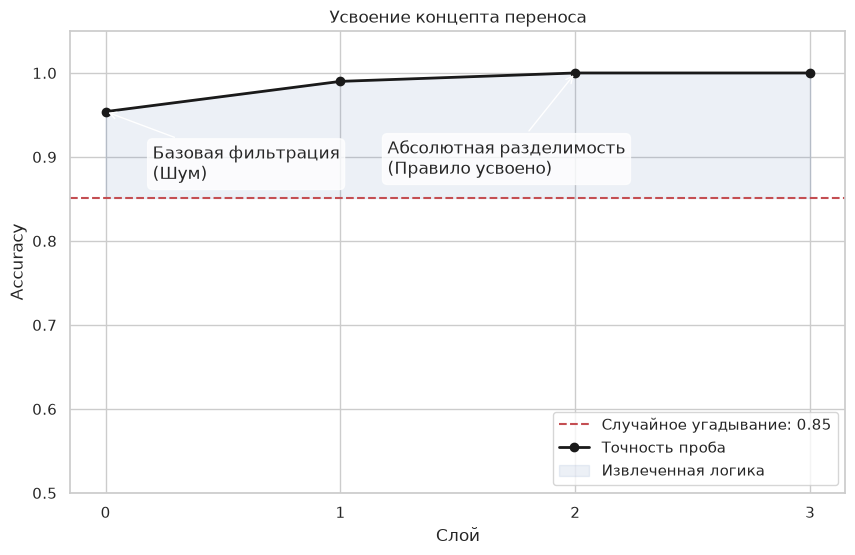

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
layers = range(model.cfg.n_layers)

ax.axhline(base_rate, color='r', ls='--', label=f'Случайное угадывание: {base_rate:.2f}')
ax.plot(layers, accuracies, 'ko-', lw=2, label='Точность проба')
ax.fill_between(layers, base_rate, accuracies, color='b', alpha=0.1, label='Извлеченная логика')

bbox = dict(boxstyle="round", fc="w", alpha=0.8)

ax.annotate('Базовая фильтрация\n(Шум)', xy=(0, accuracies[0]), 
            xytext=(0.2, accuracies[0] - 0.08), arrowprops=dict(arrowstyle="->"), bbox=bbox)

pl = next((i for i, v in enumerate(accuracies) if v > 0.99), None)
if pl is not None:
    ax.annotate('Абсолютная разделимость\n(Правило усвоено)', xy=(pl, accuracies[pl]), 
                xytext=(pl - 0.8, accuracies[pl] - 0.12), arrowprops=dict(arrowstyle="->"), bbox=bbox)

ax.set(title='Усвоение концепта переноса', xlabel='Слой', ylabel='Accuracy', ylim=(0.5, 1.05))
ax.set_xticks(layers)
ax.legend(loc='lower right')
plt.show()

# Diving deeper

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import seaborn as sns

models = {}
X_tests = {}
y_tests = {}
probas = {}

for layer in range(model.cfg.n_layers):
    X_train, X_test, y_train, y_test = train_test_split(
        X_layers_full[layer], y_full, test_size=0.2, random_state=42, stratify=y_full
    )
    probe = LogisticRegression(max_iter=2000, random_state=42)
    probe.fit(X_train, y_train)
    
    models[layer] = probe
    X_tests[layer] = X_test
    y_tests[layer] = y_test
    probas[layer] = probe.predict_proba(X_test)[:, 1]

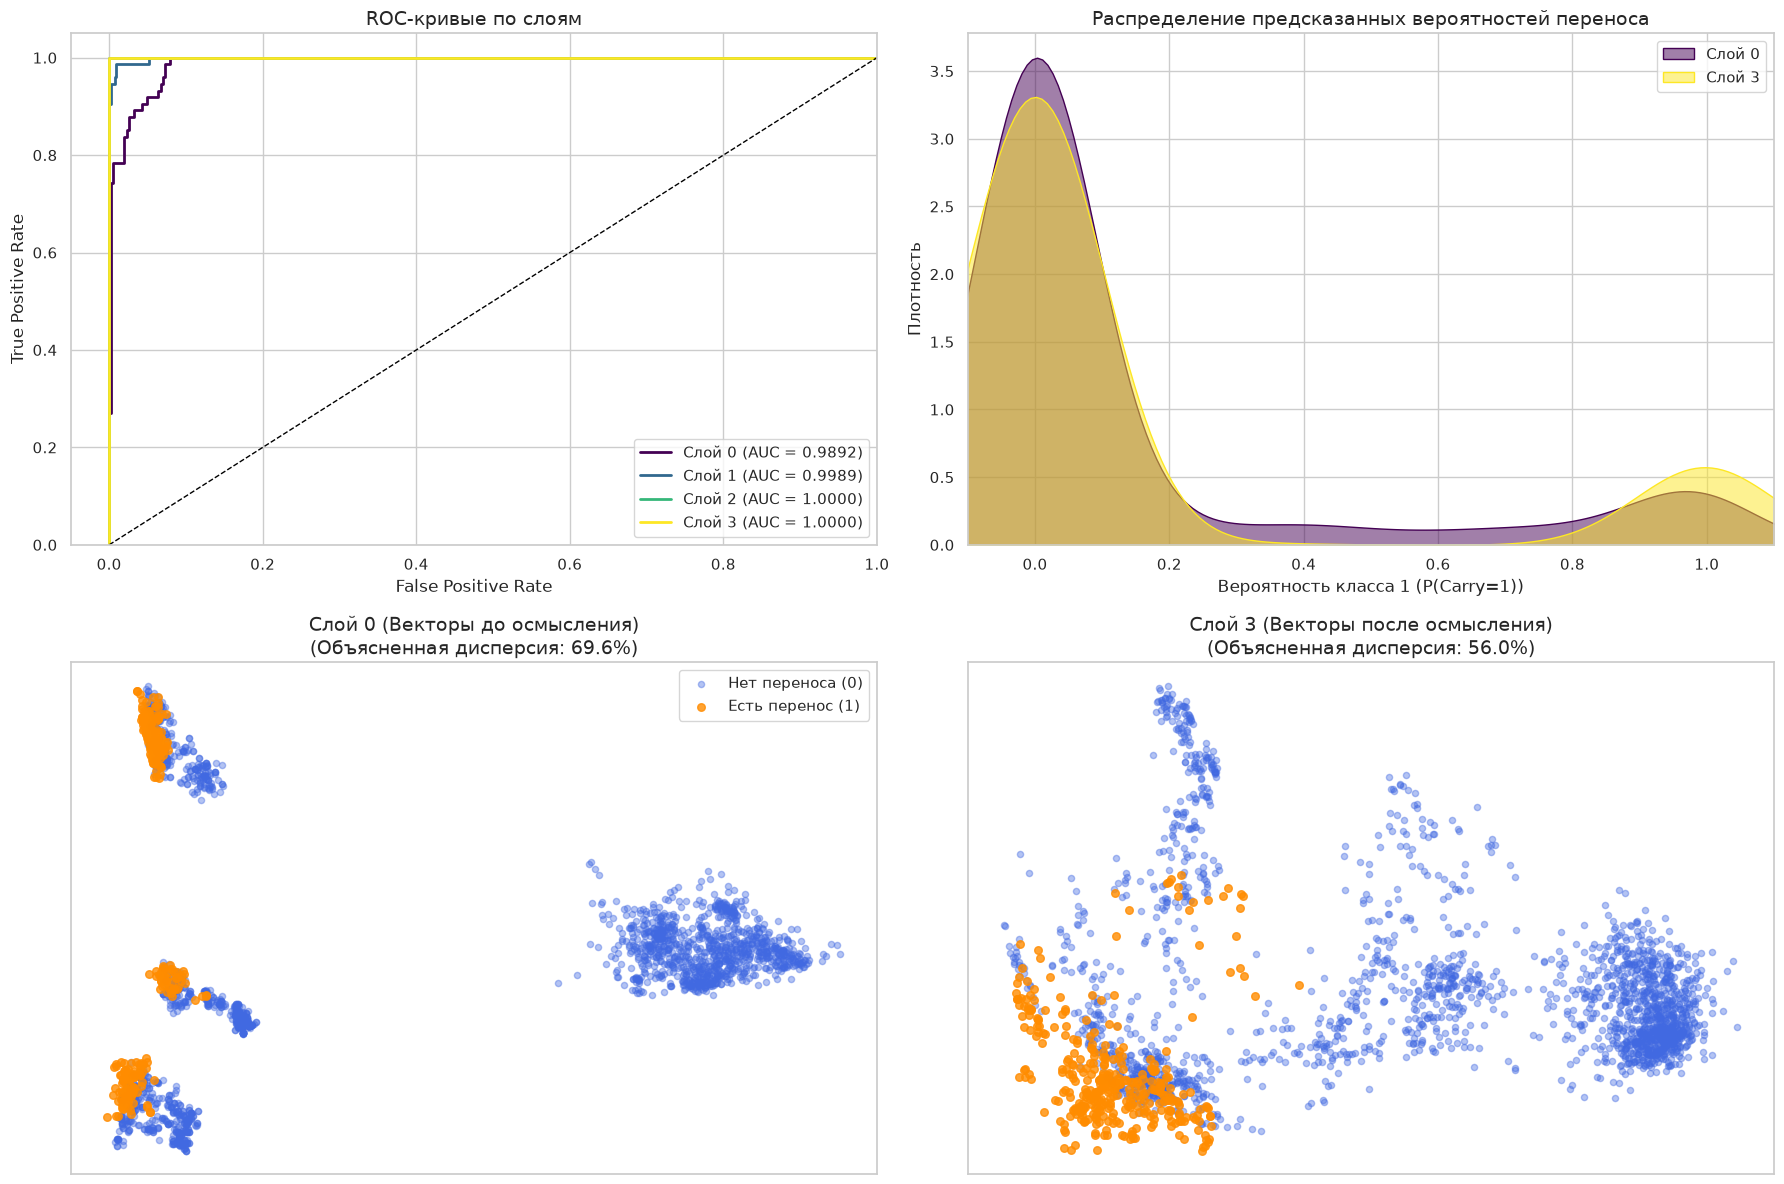

In [19]:
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(18, 12))

layers_to_plot = [0, 1, 2, 3]

ax1 = plt.subplot(2, 2, 1)
colors = plt.cm.viridis(np.linspace(0, 1, model.cfg.n_layers))

for layer, color in zip(layers_to_plot, colors):
    fpr, tpr, _ = roc_curve(y_tests[layer], probas[layer])
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, color=color, lw=2, label=f'Слой {layer} (AUC = {roc_auc:.4f})')

ax1.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--')
ax1.set_xlim([-0.05, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC-кривые по слоям', fontsize=14)
ax1.legend(loc="lower right")

ax2 = plt.subplot(2, 2, 2)
# Сравниваем самый первый и самый уверенный слои
sns.kdeplot(probas[0], fill=True, label='Слой 0', color=colors[0], ax=ax2, alpha=0.5)
sns.kdeplot(probas[3], fill=True, label='Слой 3', color=colors[-1], ax=ax2, alpha=0.5)

ax2.set_title('Распределение предсказанных вероятностей переноса', fontsize=14)
ax2.set_xlabel('Вероятность класса 1 (P(Carry=1))')
ax2.set_ylabel('Плотность')
ax2.set_xlim([-0.1, 1.1])
ax2.legend()

# Ужимаем 1024 измерения до 2
def plot_pca_manifold(layer_idx, ax, title):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_layers_full[layer_idx])
    
    mask_0 = (y_full == 0)
    mask_1 = (y_full == 1)
    
    ax.scatter(X_pca[mask_0, 0], X_pca[mask_0, 1], alpha=0.4, label='Нет переноса (0)', s=20, color='royalblue')
    ax.scatter(X_pca[mask_1, 0], X_pca[mask_1, 1], alpha=0.8, label='Есть перенос (1)', s=30, color='darkorange')
    
    variance = sum(pca.explained_variance_ratio_) * 100
    ax.set_title(f'{title}\n(Объясненная дисперсия: {variance:.1f}%)', fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])
    if layer_idx == 0:
        ax.legend()

ax3 = plt.subplot(2, 2, 3)
plot_pca_manifold(0, ax3, 'Слой 0 (Векторы до осмысления)')

ax4 = plt.subplot(2, 2, 4)
plot_pca_manifold(3, ax4, 'Слой 3 (Векторы после осмысления)')

plt.tight_layout()
plt.show()

* _Исходя из графика 1.1 видно_, что транстформер не строит логику переноса по этапно, базовый концепт формируется сразу на нулевом слое, а остальные (1-3) выступают в роли добивки для краевых случаев.
* _Исходя из графика 1.2_ — модель не сомневается в процессе работы, вероятности строго прижаты к краям, а после прохождения последнего словя зоны неуверенности у модели обученной практически не существует.
* _Исходя из графиков 2.1, 2.2_ — несмотря на то что в многомерном пространстве разделимость составила 100% (смотреть график выше), в пространстве меньшей размерности всё превращается в кашу. Интересно также, что после прохождения блоков внимания доля объяснённой дисперсии должна была увеличиться, она уменьшилась. Это вытекающее из суперпозиции признаков явление — внутри блока модель упаковывает смысл многих ортогональных или почти ортогональных контекстов в один вектор. Пространтсво усложняется и теряет "плоскость", ввиду чего просто нет "ракурса" которым PCA мог бы спроецировать его из 1024d в 2d с сохранением дисперсии. Как следствие, падение дисперсии здесь вовсе не является маркером деградации системы, а лишь маркер перехода к плотной многомерной упаковки информации.

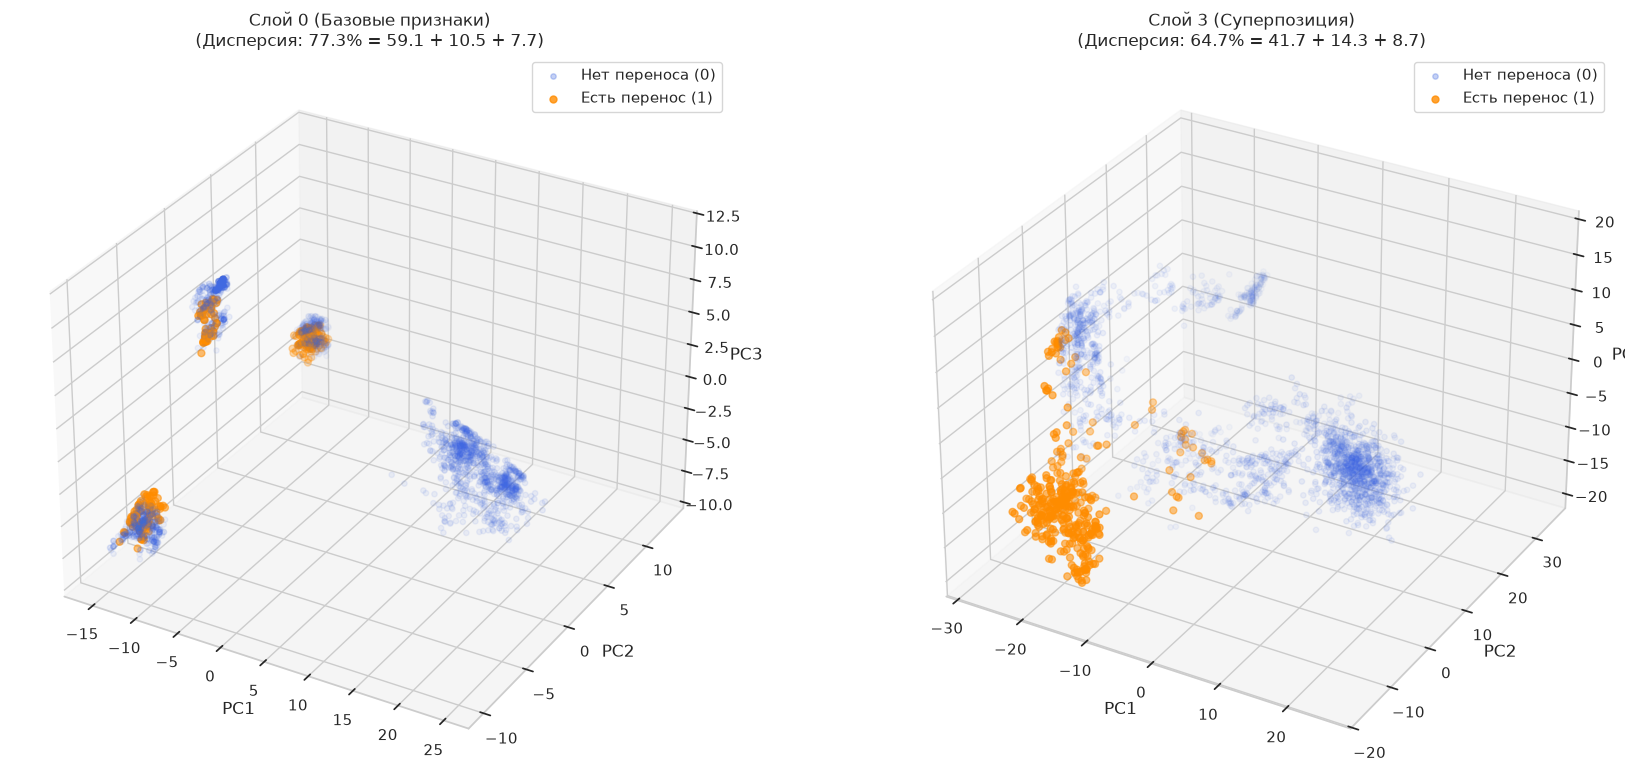

In [22]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

fig = plt.figure(figsize=(18, 8))

def plot_pca_3d(layer_idx, subplot_position, title):
    ax = fig.add_subplot(1, 2, subplot_position, projection='3d')
    
    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(X_layers_full[layer_idx])
    
    mask_0 = (y_full == 0)
    mask_1 = (y_full == 1)
    
    ax.scatter(X_pca[mask_0, 0], X_pca[mask_0, 1], X_pca[mask_0, 2], 
               alpha=0.3, label='Нет переноса (0)', s=15, color='royalblue')
    ax.scatter(X_pca[mask_1, 0], X_pca[mask_1, 1], X_pca[mask_1, 2], 
               alpha=0.8, label='Есть перенос (1)', s=25, color='darkorange')
    
    var_1, var_2, var_3 = pca.explained_variance_ratio_ * 100
    total_var = var_1 + var_2 + var_3
    
    ax.set_title(f'{title}\n(Дисперсия: {total_var:.1f}% = {var_1:.1f} + {var_2:.1f} + {var_3:.1f})', fontsize=12)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')

    ax.legend()

plot_pca_3d(0, 1, 'Слой 0 (Базовые признаки)')
plot_pca_3d(3, 2, 'Слой 3 (Суперпозиция)')

plt.tight_layout()
plt.show()

* Как ни странно, добавление третьего измерения принципиально не поменяло картину по сравнению с 2d Объясненная дисперсия выросла лишь незначительно, что окончательно подтверждает, что смыслы упакованы не в трех главных осях, а равномерно размазаны по всем остальным сотням измерений. Тем не менее, даже в этой сжатой проекции видно, как на последнем слое пространство глобально перестраивается, чтобы линейно и чисто отделить абстрактный концепт переноса от остального шума.